# Simulation study: fixed-domain MLE for the RBF kernel with a nugget

This notebook accompanies *Sharp Asymptotic Theory of Maximum Likelihood Estimation for Gaussian Processes with an RBF Kernel* (A. Qaqish and D. Li). All computation is in `rbf_mle_sim.py`; the notebook calls it, checks it against brute-force linear algebra, draws the figures, and computes every number quoted in Section 4 and Appendix D of the paper (Section 8 below).

**Model.** $Y_i = F(x_i) + \varepsilon_i$ on $[0,1]^p$, $p\in\{1,2,3\}$, where $F\sim\mathrm{GP}\big(0,\ \sigma^2 e^{-\|x-x'\|^2/(2\ell^2)}\big)$ and $\varepsilon_i\sim N(0,\tau^2)$. The design is a regular midpoint grid with $G$ points per axis, $n=G^p$. True values: $\sigma_0^2=1,\ \ell_0=0.25,\ \tau_0^2=0.01$.

**What the theorem predicts** (with $b_n=\log n/\log\log n$):

| parameter | rate | log–log check |
|---|---|---|
| $\sigma^2$ | $b_n^{-p/2}$ | RMSE vs $b_n$, slope $-p/2$ |
| $\ell$ | $b_n^{-(p+2)/2}$ | RMSE vs $b_n$, slope $-(p+2)/2$ |
| $\tau^2$ | $n^{-1/2}$, with $\sqrt n(\hat\tau^2-\tau_0^2)\Rightarrow N(0,2\tau_0^4)$ | RMSE vs $n$, slope $-1/2$, constant $\sqrt2\tau_0^2$ |

Part (v) of the theorem also gives $\mathbb E(\hat\theta_j-\theta_{0j})^2 \approx [\mathcal I_n(\theta_0)^{-1}]_{jj}$, and part (iii) gives $\mathcal I_n^{1/2}(\hat\theta-\theta_0)\Rightarrow N_3(0,I_3)$.

**How the study is designed.**

1. *Likelihood at large $n$.* The power series in the proof, $e^{-(x-x')^2/2\ell^2}=\sum_k\phi_k(x)\phi_k(x')$ with $\phi_k(x)=e^{-u^2/2}u^k/\sqrt{k!}$ and $u=(x-\tfrac12)/\ell$, reproduces the kernel to about $10^{-14}$ with $M\approx 50$–$225$ terms. So $R_n=\Phi\Phi^\top$ has numerical rank $M\ll n$, and the Gaussian likelihood, exact draws from the model and the Fisher information cost $O(nM^2)$ instead of $O(n^3)$. For $p\ge2$ the grid kernel is a Kronecker product $R_G\otimes\cdots\otimes R_G$. This makes the global MLE feasible up to $n=10^6$ in every dimension. Section 1 checks all of this against dense $O(n^3)$ linear algebra.
2. *Global MLE.* The profile likelihood in $\ell$ can have more than one local maximum, so it is evaluated on a 25-point log grid over $\Theta_\ell=[0.05,2]$, maximising over $(\sigma^2,\tau^2)\in[10^{-2},10^2]\times[10^{-4},1]$ at each $\ell$ (L-BFGS-B from several starts). Every local maximum on the grid is then refined by a bounded Brent search in $\log\ell$, and the best point is the MLE.
3. *How to read logarithmic rates.* Over any feasible range, $b_n$ changes by only a factor of about 2, so a slope fitted to RMSE alone is a weak test. We therefore also compute the exact **Fisher-information curve** $[\mathcal I_n^{-1}]_{jj}^{1/2}$ out to $n=10^8$ ($p=1$) and $n=10^{12}$ ($p=2,3$). By the theorem, this curve is the asymptotic RMSE. Two things should then hold: (a) the Monte Carlo RMSE tracks the Fisher curve, and (b) the Fisher curve becomes parallel to the $b_n^{-p/2}$ and $b_n^{-(p+2)/2}$ reference lines.
4. *Replicates and normality.* 1000 replicates for each $(p,n)$. Bootstrap 95% intervals are shown for the RMSE, normal Q–Q plots for the standardized errors, and a joint check that $\|\mathcal I_n^{1/2}(\hat\theta-\theta_0)\|^2\approx\chi^2_3$.

In [1]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from joblib import Parallel, delayed
import rbf_mle_sim as sim

print("theta0 =", sim.THETA0, "\nTheta  =", sim.BOUNDS)
for p in (1, 2, 3):
    print(f"n (p={p}):", sim.N_LIST[p])
print("replicates:", sim.N_REP)

theta0 = {'s': 1.0, 'l': 0.25, 't': 0.01} 
Theta  = {'s': (0.01, 100.0), 'l': (0.05, 2.0), 't': (0.0001, 1.0)}
n (p=1): [100, 300, 1000, 3000, 10000, 30000, 100000, 300000, 1000000]
n (p=2): [100, 324, 1024, 3136, 10000, 31684, 99856, 315844, 1000000]
n (p=3): [125, 343, 1000, 2744, 10648, 32768, 97336, 314432, 1000000]
replicates: 1000


## 1. Correctness checks against dense $O(n^3)$ code

First, the truncated power series is compared directly with the kernel and its derivative in $\ell$ (Appendix D.1 of the paper). The fast likelihood, the global MLE and the Fisher information should then agree with brute-force dense linear algebra on problems small enough for it (Appendix D.9): $n=300$, $1000$ and $4000$ for $p=1$, $G=20$ for $p=2$ and $G=6$ for $p=3$. The log-likelihood is compared at $\theta_0$ and three other parameter values, and the Fisher information with $\tfrac12\operatorname{tr}(C^{-1}C_aC^{-1}C_b)$ computed densely. The MLE is compared with a Nelder–Mead search of the dense likelihood for $n\le1000$; beyond that the search takes too long. A second check confirms that the simulated data have covariance $C_n(\theta_0)$: after whitening with $C_n(\theta_0)$, the empirical covariance of $2\times10^4$ simulated data sets should be the identity up to uncorrelated sampling errors. This cell takes a few minutes.

In [2]:
# truncated power series vs the kernel and its l-derivative: 801 points of [0, 1], 40 lengthscales in [0.05, 2]
x = np.linspace(0, 1, 801); d = x[:, None] - x[None, :]; kerr = np.zeros(2)
for l in np.exp(np.linspace(*np.log(sim.BOUNDS["l"]), 40)):
    P, dP = sim.features(x, l, sim.n_features(l), deriv=True)
    K = np.exp(-d ** 2 / (2 * l ** 2))
    kerr = np.maximum(kerr, [np.abs(P @ P.T - K).max(), np.abs(dP @ P.T + P @ dP.T - K * d ** 2 / l ** 3).max()])
print(f"truncated power series: max error {kerr[0]:.1e} (kernel), {kerr[1]:.1e} (derivative in l)\n")

def dense_design(p, G):
    # the G^p midpoint grid as an n x p array, in the same order as the data arrays
    g = sim.grid(G)
    return np.stack(np.meshgrid(*([g] * p), indexing="ij"), -1).reshape(-1, p)

rng = np.random.default_rng(1)
thetas = [(1.0, .25, .01), (2.3, .4, .05), (.4, .12, .002), (5, .06, .3)]
for p, G in [(1, 300), (1, 1000), (1, 4000), (2, 20), (3, 6)]:
    t0 = time.time()
    n = G ** p
    Y = sim.simulate(p, n, sim.THETA0, rng)
    X, y, E = dense_design(p, G), Y.ravel(), float((Y ** 2).sum())
    err = []
    for th in thetas:
        lam, z2 = sim._suffstats(p, Y, th[1])
        f, _ = sim._nll_st(np.log(th[0]), np.log(th[2]), lam, z2, n, E)
        d = sim.nll_dense(X, y, th)
        err.append([abs(f - d), abs(f - d) / abs(d)])
    err = np.max(err, axis=0)
    print(f"p={p}, n={n}: max |loglik error| = {err[0]:.1e} (relative {err[1]:.1e})")
    if n <= 1000:
        est = sim.fit_mle(p, Y)
        ref = minimize(lambda v: sim.nll_dense(X, y, np.exp(v)), np.log(est) + 0.02, method="Nelder-Mead",
                       options=dict(xatol=1e-8, fatol=1e-10, maxiter=4000))
        print(f"   MLE (fast)  = {np.round(est, 6)}\n   MLE (dense) = {np.round(np.exp(ref.x), 6)}")
    I1, I2 = sim.fisher_information(p, n, sim.THETA0), sim.fisher_dense(X, sim.THETA0)
    print(f"   Fisher information relative error = {np.abs(I1 - I2).max() / np.abs(I2).max():.1e}   [{time.time() - t0:.0f}s]")

# data generation: 2 x 10^4 simulated data sets should have covariance C_n(theta0). Whitened with C_n(theta0),
# they should have identity covariance, and the entries of their empirical covariance are then uncorrelated,
# with SD sqrt(2/N) on the diagonal and 1/sqrt(N) off it.
for p, G in [(1, 40), (2, 6), (3, 4)]:
    X = dense_design(p, G); n = len(X)
    D2 = ((X[:, None, :] - X[None, :, :]) ** 2).sum(-1)
    C = sim.THETA0["s"] * np.exp(-D2 / (2 * sim.THETA0["l"] ** 2)) + sim.THETA0["t"] * np.eye(n)
    w, U = np.linalg.eigh(C)
    N = 20000
    Z = np.array([sim.simulate(p, n, sim.THETA0, rng).ravel() for _ in range(N)]) @ U / np.sqrt(w)
    se = np.where(np.eye(n, dtype=bool), np.sqrt(2 / N), np.sqrt(1 / N))
    z = np.abs((Z.T @ Z / N - np.eye(n)) / se)[np.triu_indices(n)]      # standardized deviations
    print(f"p={p}, n={n}: {z.size} entries of the whitened covariance; mean squared standardized deviation "
          f"{np.mean(z ** 2):.2f} (expected 1), {np.mean(z > 1.96):.1%} beyond 1.96 (expected 5%), largest {z.max():.2f}")

truncated power series: max error 9.3e-15 (kernel), 4.3e-13 (derivative in l)



p=1, n=300: max |loglik error| = 1.2e-08 (relative 4.6e-11)


   MLE (fast)  = [0.184013 0.201471 0.008499]
   MLE (dense) = [0.184013 0.201471 0.008499]
   Fisher information relative error = 6.1e-14   [21s]


p=1, n=1000: max |loglik error| = 1.9e-07 (relative 4.7e-10)


   MLE (fast)  = [1.093627 0.250948 0.010695]
   MLE (dense) = [1.093622 0.250948 0.010695]


...

p=3, n=216: max |loglik error| = 2.9e-11 (relative 6.9e-13)


   MLE (fast)  = [0.978376 0.240994 0.007042]
   MLE (dense) = [0.978376 0.240994 0.007042]
   Fisher information relative error = 1.5e-14   [21s]


p=1, n=40: 820 entries of the whitened covariance; mean squared standardized deviation 0.92 (expected 1), 4.6% beyond 1.96 (expected 5%), largest 3.32


p=2, n=36: 666 entries of the whitened covariance; mean squared standardized deviation 0.96 (expected 1), 4.7% beyond 1.96 (expected 5%), largest 3.56


p=3, n=64: 2080 entries of the whitened covariance; mean squared standardized deviation 0.99 (expected 1), 4.4% beyond 1.96 (expected 5%), largest 3.71


## 2. Run (or load) the simulation

The full study (`python rbf_mle_sim.py`) takes about 8–9 hours on a 4-core laptop; most of that is $p=1$ with $n\ge3\times10^5$. The saved results in `results/` are loaded when present. Set `RUN = "quick"` for a 3-minute version with fewer sample sizes and 200 replicates (written to `results_quick/` and `figures_quick/`), or `RUN = "full"` to redo everything (this overwrites `results/` and `figures/`).

In [3]:
RUN = "load"   # "load" | "quick" | "full"
DIMS = (1, 2, 3)  # dimensions to (re)run when RUN != "load"
RESDIR = "results_quick" if RUN == "quick" else "results"
FIGDIR = "figures_quick" if RUN == "quick" else "figures"

if RUN in ("quick", "full"):
    cfg = sim.QUICK if RUN == "quick" else dict(N_LIST=sim.N_LIST, N_REP=sim.N_REP, N_FISHER=sim.N_FISHER)
    for p in DIMS:
        sim.run_all(p, cfg, outdir=RESDIR)

PS = [p for p in (1, 2, 3) if os.path.exists(os.path.join(RESDIR, f"sim_p{p}.npz"))]
res = {p: sim.load(os.path.join(RESDIR, f"sim_p{p}.npz")) for p in PS}
for p in PS:
    sim.print_table(res[p])


p = 1
        n    b_n |  RMSE(s)  asy.SD | RMSE(l)  asy.SD | sqrt(n)RMSE(t)  sqrt2 t0 | at-bound(s,l,t)
      100  3.015 | 1.3802  0.7133 | 0.08768 0.03723 |   0.01514     0.01414 | 0.000 0.001 0.000
      300  3.276 | 1.0210  0.6930 | 0.05500 0.03187 |   0.01405     0.01414 | 0.000 0.000 0.000
     1000  3.574 | 0.9918  0.6730 | 0.04614 0.02744 |   0.01429     0.01414 | 0.000 0.000 0.000
     3000  3.849 | 1.3433  0.6562 | 0.03699 0.02424 |   0.01378     0.01414 | 0.000 0.000 0.000
    10000  4.148 | 0.9304  0.6395 | 0.03072 0.02147 |   0.01380     0.01414 | 0.000 0.000 0.000
    30000  4.419 | 0.8938  0.6253 | 0.02700 0.01938 |   0.01415     0.01414 | 0.000 0.000 0.000
   100000  4.712 | 0.7789  0.6111 | 0.02365 0.01750 |   0.01350     0.01414 | 0.000 0.000 0.000
   300000  4.976 | 0.7055  0.5989 | 0.02104 0.01603 |   0.01488     0.01414 | 0.000 0.000 0.000
  1000000  5.261 | 0.6952  0.5866 | 0.01923 0.01469 |   0.01453     0.01414 | 0.000 0.000 0.000



p = 2
        n    b_n |  RMSE(s)  asy.SD | RMSE(l)  asy.SD | sqrt(n)RMSE(t)  sqrt2 t0 | at-bound(s,l,t)
      100  3.015 | 0.4246  0.3962 | 0.02150 0.01924 |   0.01844     0.01414 | 0.000 0.000 0.000
      324  3.295 | 0.4030  0.3658 | 0.01629 0.01504 |   0.01545     0.01414 | 0.000 0.000 0.000
     1024  3.580 | 0.3564  0.3438 | 0.01272 0.01237 |   0.01528     0.01414 | 0.000 0.000 0.000
     3136  3.860 | 0.3236  0.3259 | 0.01072 0.01048 |   0.01393     0.01414 | 0.000 0.000 0.000
    10000  4.148 | 0.3317  0.3098 | 0.00952 0.00899 |   0.01455     0.01414 | 0.000 0.000 0.000
    31684  4.432 | 0.3049  0.2956 | 0.00787 0.00782 |   0.01422     0.01414 | 0.000 0.000 0.000
    99856  4.711 | 0.2946  0.2828 | 0.00693 0.00688 |   0.01441     0.01414 | 0.000 0.000 0.000
   315844  4.988 | 0.2892  0.2712 | 0.00642 0.00612 |   0.01414     0.01414 | 0.000 0.000 0.000
  1000000  5.261 | 0.2655  0.2606 | 0.00561 0.00548 |   0.01430     0.01414 | 0.000 0.000 0.000



p = 3
        n    b_n |  RMSE(s)  asy.SD | RMSE(l)  asy.SD | sqrt(n)RMSE(t)  sqrt2 t0 | at-bound(s,l,t)
      125  3.067 | 0.2660  0.2601 | 0.01453 0.01417 |   0.04003     0.01414 | 0.000 0.000 0.002
      343  3.309 | 0.2270  0.2200 | 0.00961 0.00947 |   0.02084     0.01414 | 0.000 0.000 0.000
     1000  3.574 | 0.2065  0.1951 | 0.00761 0.00716 |   0.01626     0.01414 | 0.000 0.000 0.000
     2744  3.827 | 0.1802  0.1784 | 0.00583 0.00581 |   0.01453     0.01414 | 0.000 0.000 0.000
    10648  4.164 | 0.1663  0.1613 | 0.00469 0.00458 |   0.01405     0.01414 | 0.000 0.000 0.000
    32768  4.440 | 0.1494  0.1499 | 0.00387 0.00385 |   0.01424     0.01414 | 0.000 0.000 0.000
    97336  4.705 | 0.1426  0.1404 | 0.00328 0.00330 |   0.01363     0.01414 | 0.000 0.000 0.000
   314432  4.987 | 0.1327  0.1315 | 0.00295 0.00284 |   0.01496     0.01414 | 0.000 0.000 0.000
  1000000  5.261 | 0.1272  0.1237 | 0.00253 0.00248 |   0.01330     0.01414 | 0.000 0.000 0.000


The table shows, on the original scale: Monte Carlo RMSE next to the asymptotic SD $[\mathcal I_n(\theta_0)^{-1}]_{jj}^{1/2}$ (columns 'asy.SD'); $\sqrt n\,\mathrm{RMSE}(\hat\tau^2)$ next to its limit $\sqrt2\,\tau_0^2$; and the share of estimates lying on the boundary of $\Theta$.

## 3. Figures 1–3 of the paper (log scale)

The paper reports results for $(\log\sigma^2,\log\ell,\log\tau^2)$. By the delta method the rates are unchanged, the asymptotic SD becomes $[\mathcal I_n(\theta_0)^{-1}]_{jj}^{1/2}/\theta_{0j}$, and $\sqrt n(\log\hat\tau^2-\log\tau_0^2)\Rightarrow N(0,2)$ with no unknown constant. The normal approximation is also visibly better on this scale.

**Top row:** log–log rate plots. For $\sigma^2$ and $\ell$ the horizontal axis is $b_n$ (with $n$ on the top axis), so the theoretical rate is a straight line. Filled circles are Monte Carlo RMSEs, which check the moment statement (v). Open squares are the robust spread $\mathrm{IQR}/1.349$, which checks the $O_{\mathbb P}$ rates (ii) and is not driven by a few large estimates. Both carry bootstrap 95% intervals. The grey line is the asymptotic SD. It is not fitted to the simulations: for each $n$ it is computed exactly from the expected Fisher information $[\mathcal I_n(\theta_0)]_{ab}=\tfrac12\operatorname{tr}(C^{-1}\partial_aC\,C^{-1}\partial_bC)$ of the actual grid design at the true parameter. It needs no simulation, so it is extended into the shaded region beyond the simulated range. The dashed line is the theoretical rate, anchored at the right end; for $\tau^2$ it has no free constant.

**Bottom row:** normal Q–Q plots of the standardized errors at small, medium and the largest $n$, shaded from light to dark as $n$ grows. The grey band is the pointwise 95% range for 1000 draws from an exact $N(0,1)$. Points beyond the frame are drawn as triangles on its top or bottom edge.

The figures are saved as `figures/rbf_mle_log_p{1,2,3}.pdf` (and `.png`).

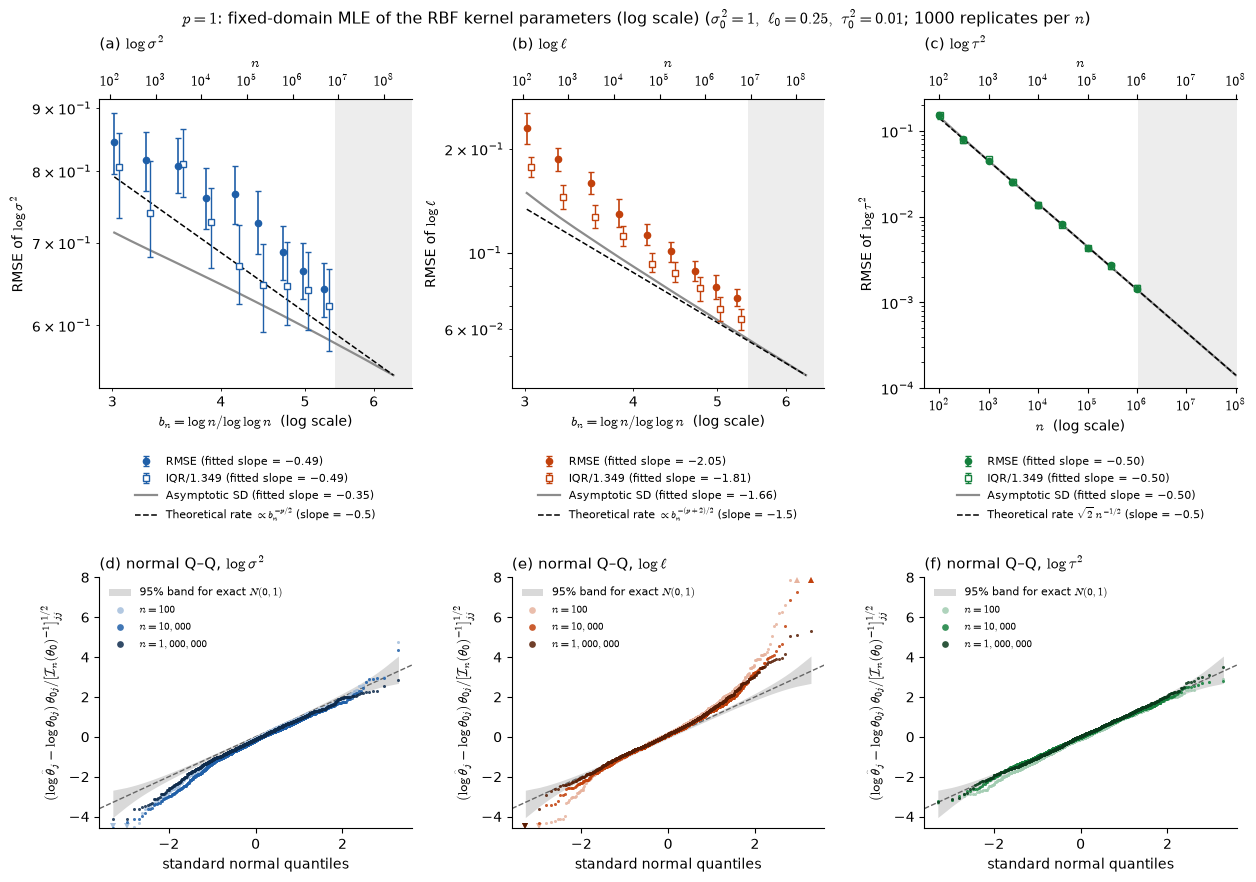

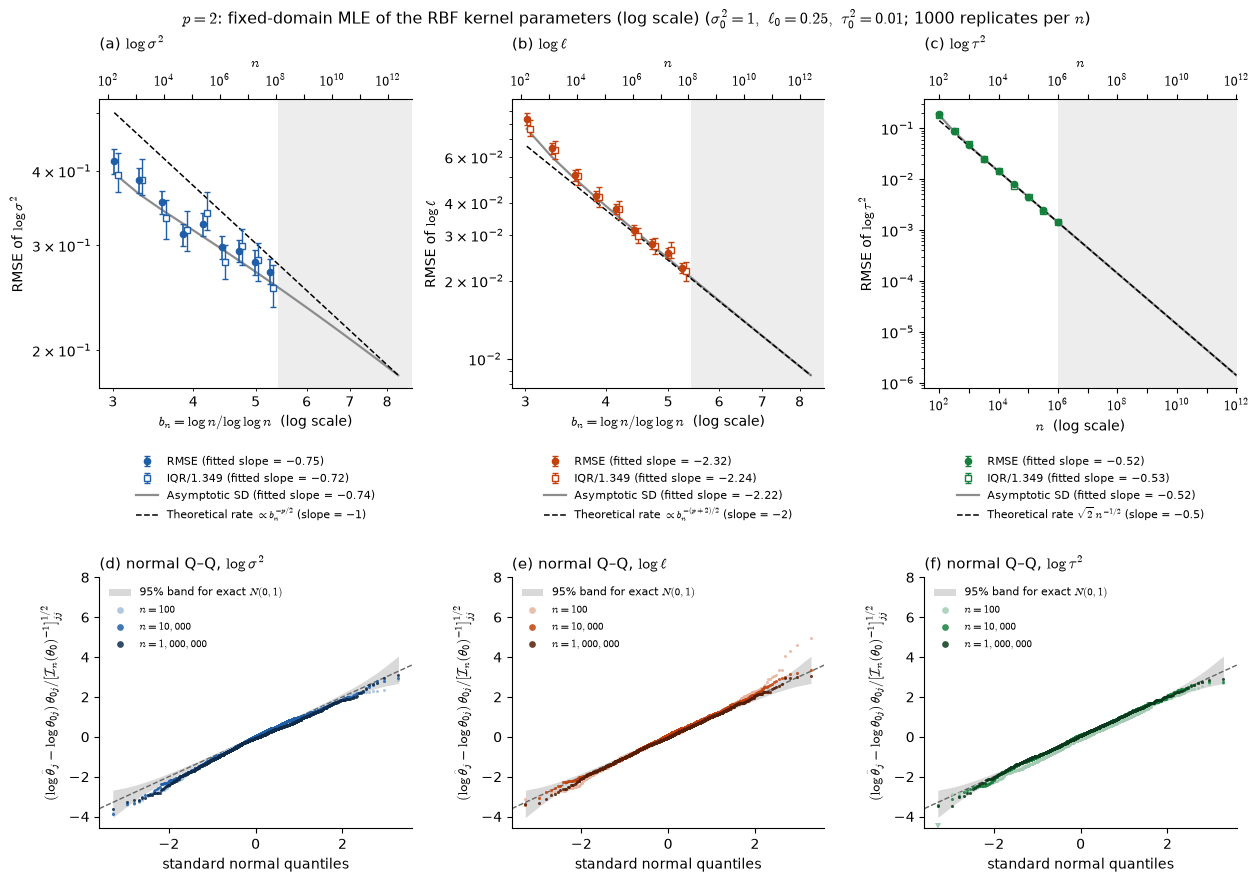

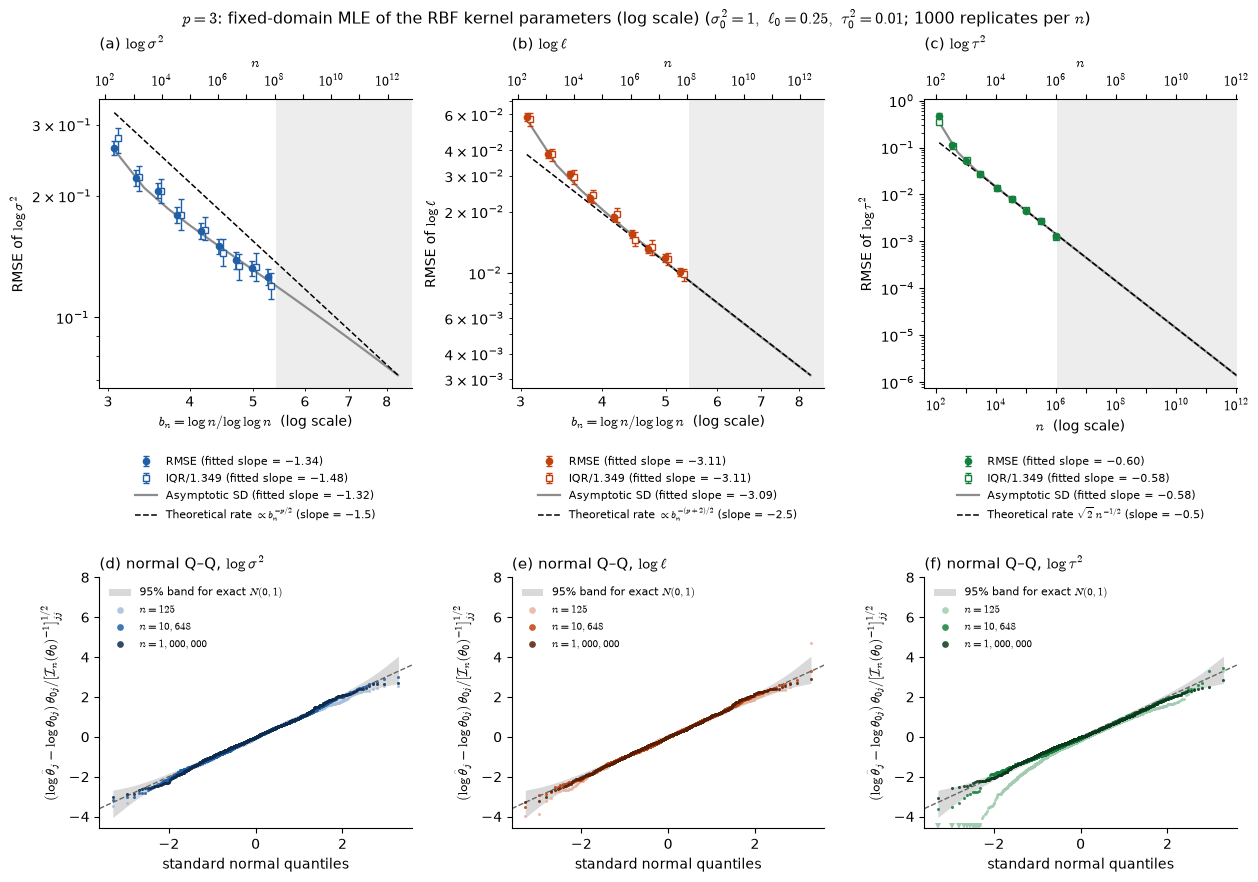

In [4]:
os.makedirs(FIGDIR, exist_ok=True)
for p in PS:
    sim.make_figure(res[p], os.path.join(FIGDIR, f"rbf_mle_log_p{p}.pdf"), log=True)
    plt.show()

### Figures A1–A3 (original scale)

The same figures for $(\sigma^2,\ell,\tau^2)$ themselves, saved as `figures/rbf_mle_p{1,2,3}.pdf`. On this scale $\hat\sigma^2=\exp(\log\hat\sigma^2)$ inherits a lognormal-type right tail when only a few Taylor coefficients are effectively available (as for $p=1$). Section 8 checks that such large values are global maxima of the likelihood on the $\sigma^2$–$\ell$ ridge, not optimisation failures.

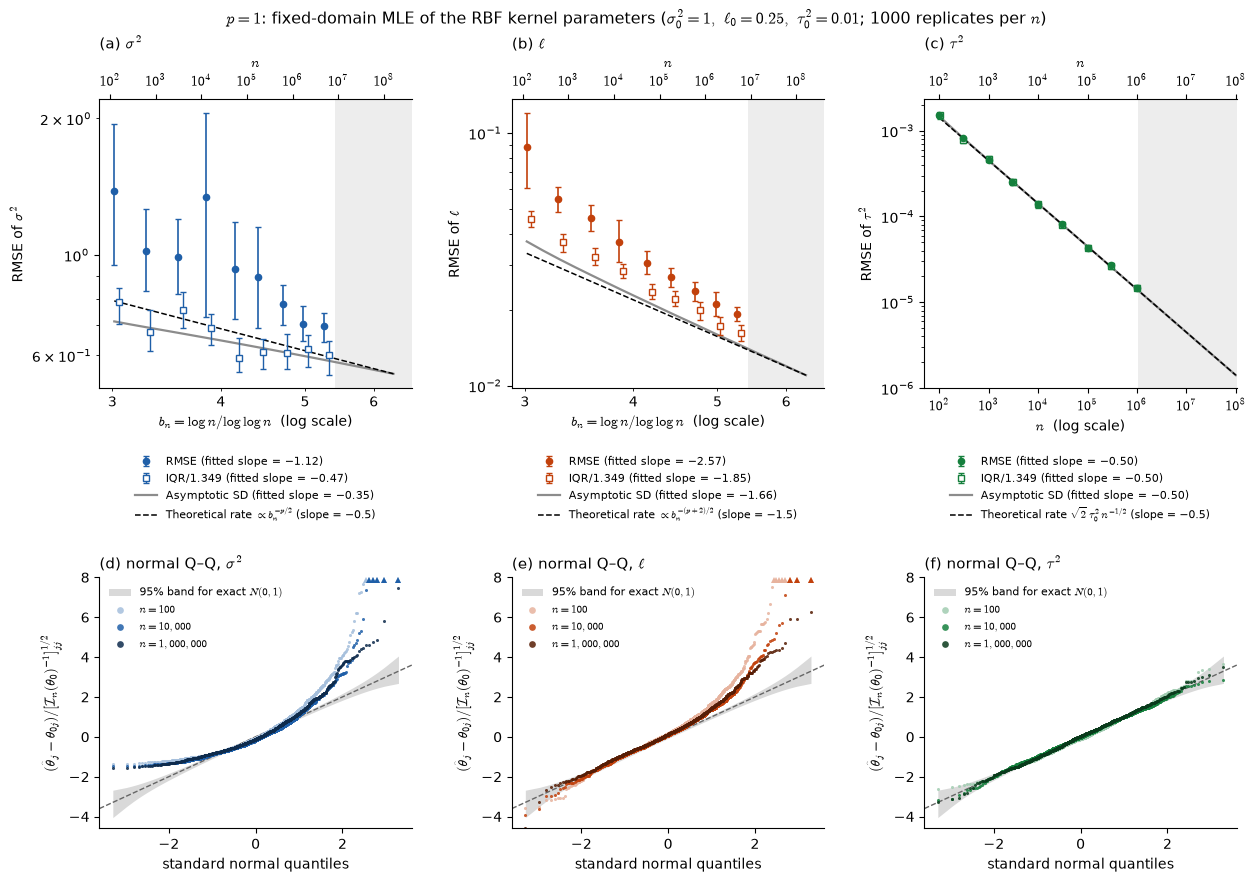

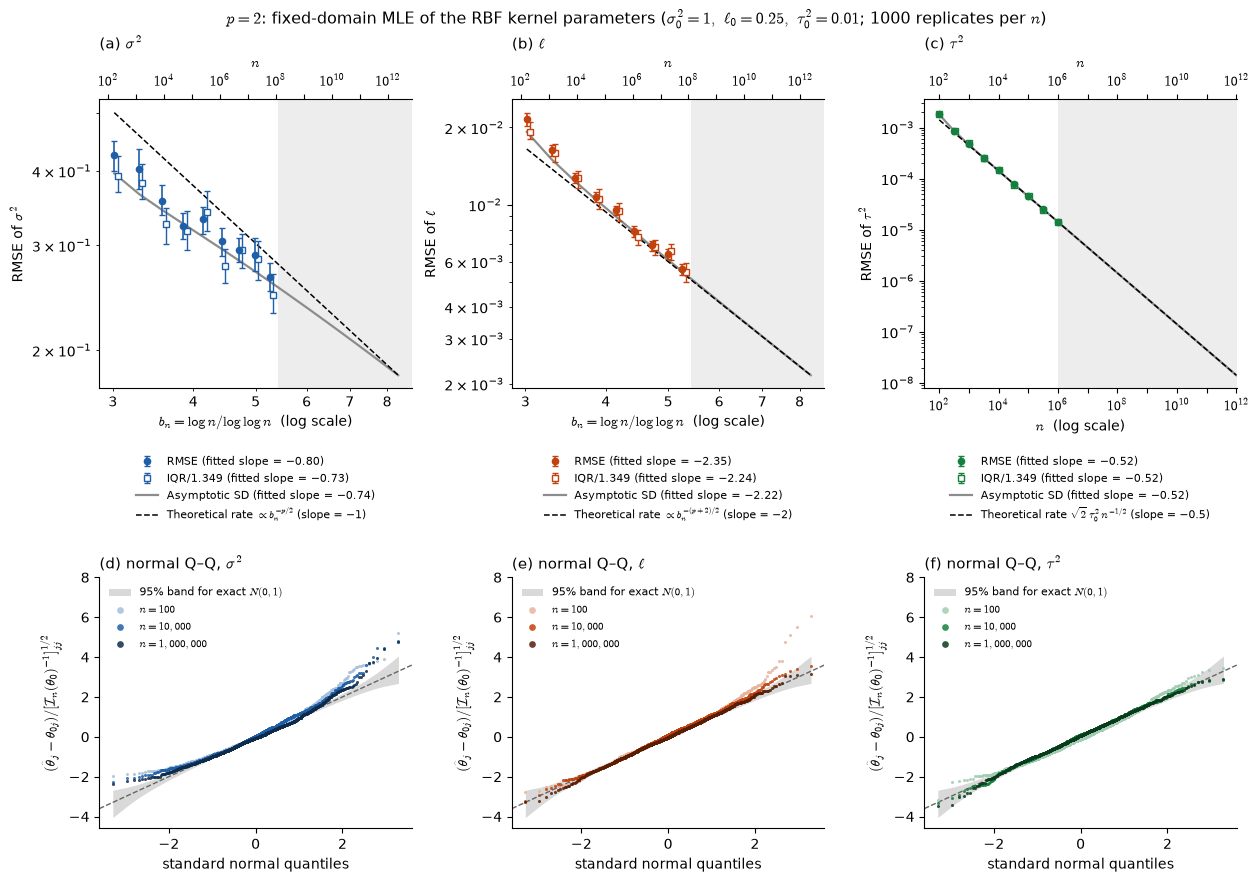

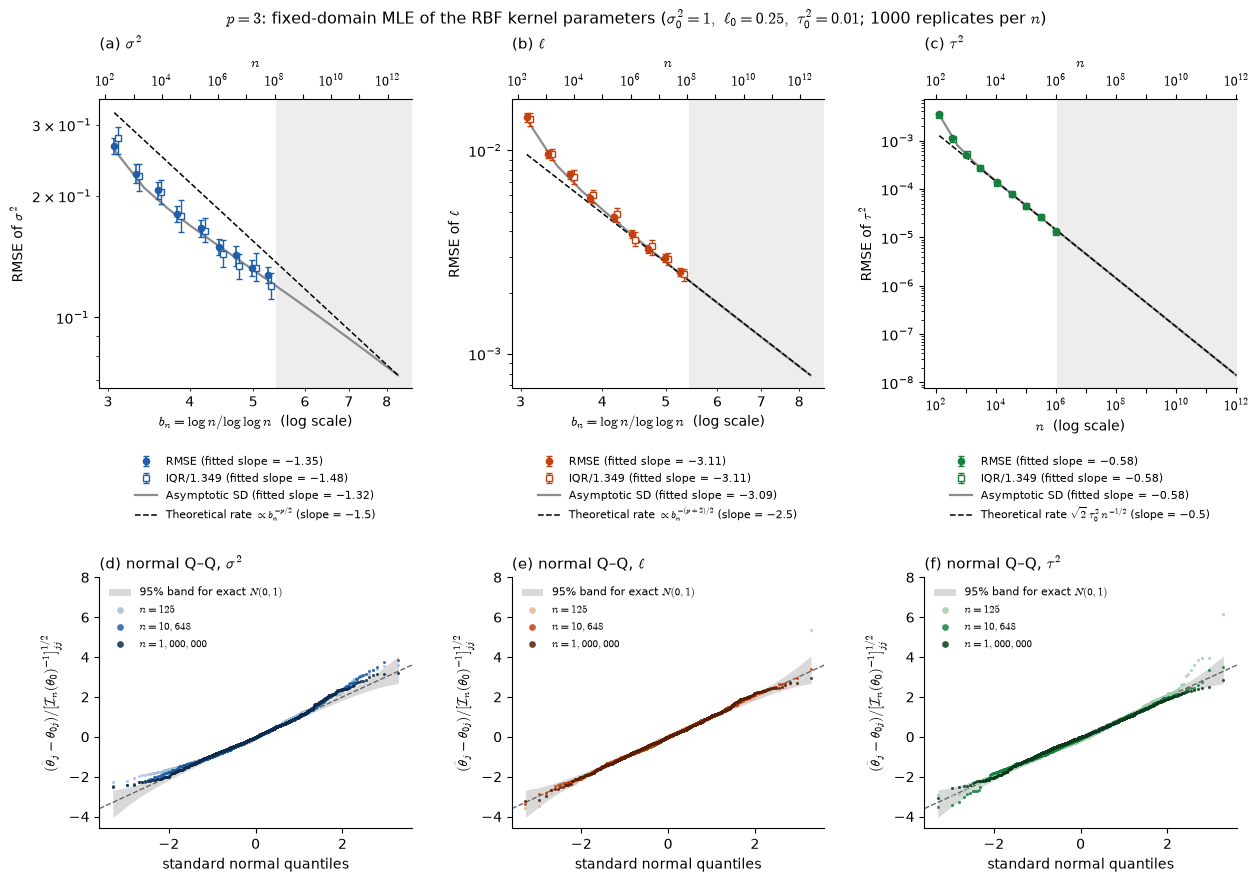

In [5]:
for p in PS:
    sim.make_figure(res[p], os.path.join(FIGDIR, f"rbf_mle_p{p}.pdf"))
    plt.show()

## 4. Bounded rescaled error

The theorem states rates up to constants: $b_n^{p/2}\,\mathrm{RMSE}(\hat\sigma^2)$, $b_n^{(p+2)/2}\,\mathrm{RMSE}(\hat\ell)$ and $\sqrt n\,\mathrm{RMSE}(\hat\tau^2)$ should stay bounded away from $0$ and $\infty$. For comparison, the $\sigma^2$ panel also shows $\sqrt n\,\mathrm{RMSE}$, which a parametric $n^{-1/2}$ rate would require to be bounded. It diverges, confirming that $\sigma^2$ and $\ell$ are only logarithmically estimable.

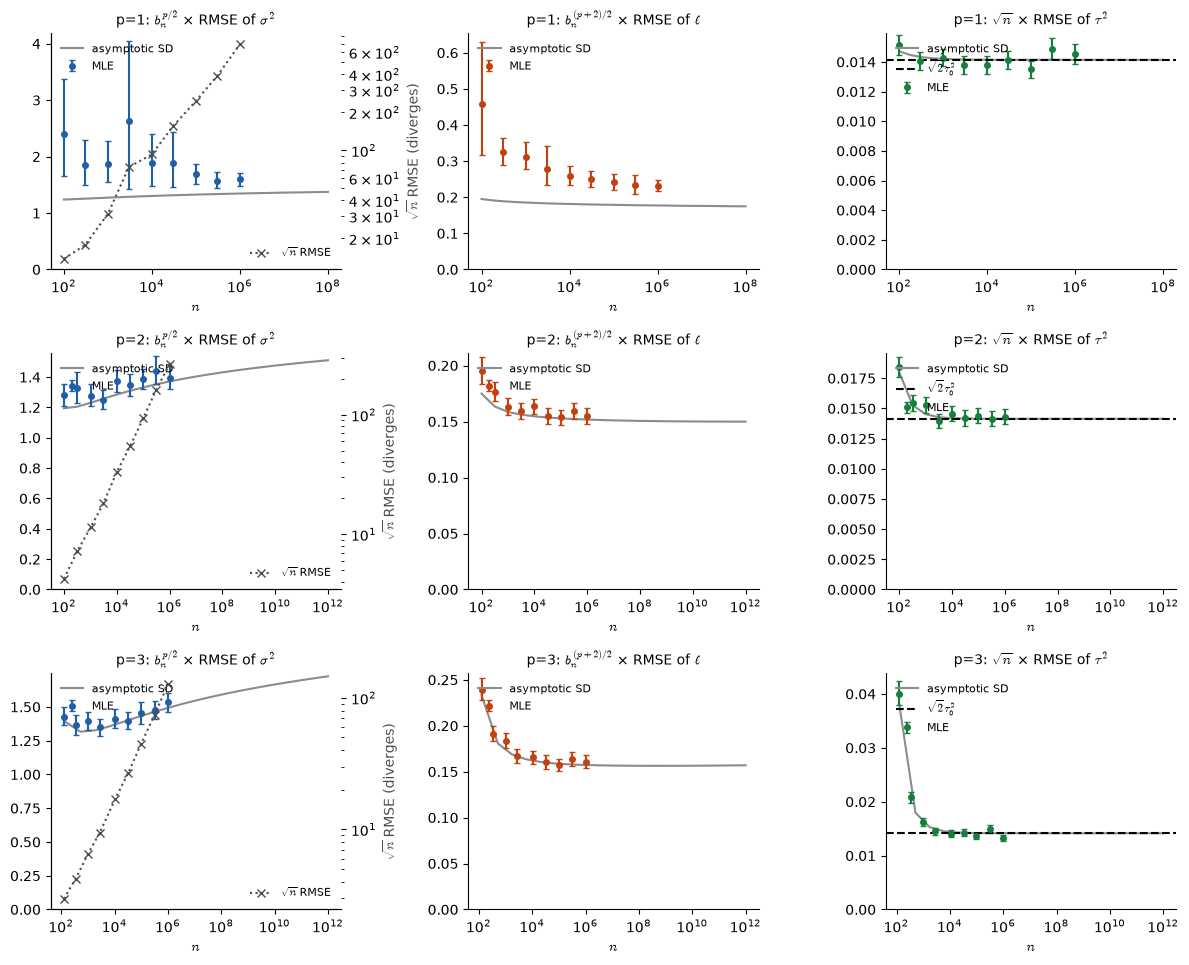

In [6]:
fig, axes = plt.subplots(len(PS), 3, figsize=(12, 3.25 * len(PS)), squeeze=False)
for r, p in enumerate(PS):
    S = sim.summarize(res[p]); n, nF = S["n"], res[p]["n_fisher"]
    sdF = np.sqrt(np.diagonal(res[p]["V_fisher"], axis1=1, axis2=2))
    scal = [lambda m: sim.b_n(m) ** (p / 2), lambda m: sim.b_n(m) ** ((p + 2) / 2), lambda m: np.sqrt(m)]
    names = [r"$b_n^{p/2}$", r"$b_n^{(p+2)/2}$", r"$\sqrt{n}$"]
    for j in range(3):
        ax = axes[r, j]
        ax.plot(nF, scal[j](nF) * sdF[:, j], "-", color="0.55", label="asymptotic SD")
        ax.errorbar(n, scal[j](n) * S["rmse"][:, j],
                    yerr=[scal[j](n) * (S["rmse"][:, j] - S["lo"][:, j]), scal[j](n) * (S["hi"][:, j] - S["rmse"][:, j])],
                    fmt="o", ms=4, color=sim.COL[j], capsize=2, label="MLE")
        if j == 2: ax.axhline(np.sqrt(2) * res[p]["theta0"][2], ls="--", color="k", label=r"$\sqrt{2}\tau_0^2$")
        if j == 0:
            ax2 = ax.twinx(); ax2.plot(n, np.sqrt(n) * S["rmse"][:, 0], "x:", color="0.3", label=r"$\sqrt{n}\,$RMSE")
            ax2.set_yscale("log"); ax2.set_ylabel(r"$\sqrt{n}\,$RMSE (diverges)", color="0.3"); ax2.legend(loc="lower right", frameon=False, fontsize=8)
        ax.set_xscale("log"); ax.set_ylim(0, None); ax.set_xlabel("$n$")
        ax.set_title(f"p={p}: {names[j]} × RMSE of {sim.PAR_LABELS[j]}", fontsize=10)
        ax.legend(frameon=False, fontsize=8, loc="upper left")
fig.tight_layout(); plt.show()

## 5. Local slopes of the asymptotic SD (Appendix D.8)

Local slopes $d\log[\mathcal I_n^{-1}]_{jj}^{1/2}/d\log b_n$ show how fast the asymptotic exponents are reached. They are the same on the original and the log scale. Because the rates are doubly logarithmic, pre-asymptotic effects (for example, the domain-to-lengthscale ratio, which fixes how many Taylor coefficients are "free" at small $n$) fade only slowly. The first three lines for each $p$ are the slopes quoted in the paper: between the smallest simulated $n$ and $n\approx10^3$, between the two largest simulated $n$ ("near $n=10^6$"), and over the last interval of the Fisher curve.

In [7]:
def local_slope(nn, sd, a, b):
    # slope of log sd against log b_n between nn[a] and nn[b], for sigma^2 and ell
    return (np.log(sd[b, :2]) - np.log(sd[a, :2])) / (np.log(sim.b_n(nn[b])) - np.log(sim.b_n(nn[a])))

for p in PS:
    n = res[p]["n"]; sd = np.sqrt(np.diagonal(res[p]["V"], axis1=1, axis2=2))
    nF = res[p]["n_fisher"]; sdF = np.sqrt(np.diagonal(res[p]["V_fisher"], axis1=1, axis2=2))
    k3 = int(np.argmin(np.abs(np.log(n / 1e3))))           # simulated n closest to 10^3
    print(f"p={p}: target slopes {-p/2:g} (sigma^2), {-(p+2)/2:g} (ell)")
    for lab, nn, s, a, b in [("", n, sd, 0, k3), ("", n, sd, -2, -1), ("  (end of the Fisher curve)", nF, sdF, -2, -1)]:
        sl = local_slope(nn, s, a, b)
        print(f"   n = {nn[a]:.3g} to {nn[b]:.3g}:  slope sigma^2 = {sl[0]:6.3f}   slope ell = {sl[1]:6.3f}{lab}")
    print("   all intervals of the Fisher curve:")
    for k in range(len(nF) - 1):
        sl = local_slope(nF, sdF, k, k + 1)
        print(f"      n = {nF[k]:9.3g} to {nF[k + 1]:9.3g}:  {sl[0]:6.3f}  {sl[1]:6.3f}")

p=1: target slopes -0.5 (sigma^2), -1.5 (ell)
   n = 100 to 1e+03:  slope sigma^2 = -0.342   slope ell = -1.796
   n = 3e+05 to 1e+06:  slope sigma^2 = -0.370   slope ell = -1.568
   n = 5.62e+07 to 1e+08:  slope sigma^2 = -0.386   slope ell = -1.536  (end of the Fisher curve)
   all intervals of the Fisher curve:
      n =       100 to       178:  -0.354  -1.924
      n =       178 to       316:  -0.342  -1.822
      n =       316 to       562:  -0.336  -1.743
      n =       562 to     1e+03:  -0.336  -1.689
      n =     1e+03 to  1.78e+03:  -0.341  -1.676
      n =  1.78e+03 to  3.16e+03:  -0.342  -1.664
      n =  3.16e+03 to  5.62e+03:  -0.343  -1.629
      n =  5.62e+03 to     1e+04:  -0.348  -1.610
      n =     1e+04 to  1.78e+04:  -0.354  -1.624
      n =  1.78e+04 to  3.16e+04:  -0.356  -1.623
      n =  3.16e+04 to  5.62e+04:  -0.356  -1.591
      n =  5.62e+04 to     1e+05:  -0.362  -1.579
      n =     1e+05 to  1.78e+05:  -0.369  -1.603
      n =  1.78e+05 to  3.16e+05: 

## 6. Normality: summary statistics and the joint $\chi^2_3$ check (Appendix D.6)

For each $n$, the tables list the skewness and excess kurtosis of each standardized coordinate (both $0$ under normality), the Kolmogorov–Smirnov distance to $N(0,1)$, and the mean of $Q=\|\mathcal I_n^{1/2}(\hat\theta-\theta_0)\|^2$, which is $3$ under the joint normal limit. The paper reports the log scale; the original scale is shown for comparison. On the original scale $\hat\sigma^2$ is right-skewed: it effectively averages only about $b_n^p$ squared Taylor coefficients, like a scaled $\chi^2$ with few degrees of freedom. The skewness decreases with $n$, more quickly for larger $p$. The figure is the joint Q–Q plot of $Q$ at the largest $n$, on the log scale.


=== log scale ===
p = 1:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)
  n=     100   -0.46   1.27  -0.15     1.13   9.06  -0.05   0.068 0.100 0.055     5.10
  n=     300   -0.45   0.72  -0.03     0.84   3.61   0.04   0.081 0.085 0.049     4.89
  n=    1000   -0.41   0.89   0.03     0.46   3.22  -0.13   0.103 0.091 0.018     4.90
  n=    3000   -0.47   0.81  -0.10     1.28   6.72   0.24   0.073 0.083 0.025     4.15
  n=   10000   -0.43   0.79  -0.08     0.70   3.59   0.13   0.091 0.068 0.019     4.26
  n=   30000   -0.55   0.73  -0.07     1.27   2.69   0.02   0.065 0.058 0.012     4.11
  n=  100000   -0.34   0.79  -0.04     0.39   2.83  -0.20   0.073 0.070 0.019     4.02
  n=  300000   -0.47   0.78  -0.09     0.52   4.40   0.16   0.055 0.060 0.021     3.97


  n= 1000000   -0.39   0.46   0.03     0.41   1.18  -0.01   0.057 0.078 0.021     4.08
p = 2:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)
  n=     100   -0.35   0.25  -0.08     0.20   1.00   0.04   0.035 0.020 0.062     3.44
  n=     324   -0.18   0.02  -0.15     0.16   0.09  -0.26   0.046 0.030 0.036     3.30


  n=    1024   -0.23   0.00   0.07    -0.02   0.15  -0.28   0.050 0.032 0.037     3.22
  n=    3136   -0.18   0.12  -0.05    -0.05  -0.15  -0.15   0.027 0.029 0.045     3.12
  n=   10000   -0.30  -0.02  -0.12    -0.03  -0.07  -0.05   0.034 0.057 0.049     3.29
  n=   31684   -0.11   0.12   0.13    -0.00   0.12   0.06   0.040 0.018 0.033     3.10
  n=   99856   -0.17  -0.11   0.06    -0.22   0.00  -0.21   0.044 0.032 0.027     3.14
  n=  315844   -0.21  -0.02   0.03     0.30   0.07  -0.09   0.029 0.030 0.019     3.19
  n= 1000000   -0.26  -0.07  -0.10     0.22   0.10   0.04   0.054 0.016 0.032     3.14
p = 3:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)
  n=     125   -0.15  -0.17  -2.93    -0.23   0.51  21.88   0.038 0.023 0.070     4.06
  n=     343   -0.07  -0.06  -0.31     0.14   0.02   0.49   0.032 0.016 0.040     3.09
  n=    1000   -0.10  -0.03  -0.01    -0.18   0.09  -0.23   0.037 0.031 0.036     3.23
  n=    2744   -0.08  -0.01 

  n=   10648   -0.01   0.03  -0.01    -0.01  -0.08   0.32   0.029 0.032 0.038     2.98
  n=   32768   -0.06  -0.07  -0.13    -0.01   0.33  -0.14   0.044 0.038 0.021     2.96
  n=   97336    0.08   0.11  -0.02     0.28  -0.10  -0.30   0.025 0.023 0.024     2.84


  n=  314432   -0.11   0.07   0.06    -0.05   0.08  -0.22   0.017 0.020 0.044     3.17
  n= 1000000   -0.05   0.00  -0.05     0.01  -0.02   0.02   0.017 0.018 0.031     2.95

=== original scale ===
p = 1:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)
  n=     100   10.27   9.53   0.29   195.28 171.05   0.07   0.094 0.121 0.055    10.73
  n=     300    4.72   2.22   0.22    51.10  10.10   0.09   0.090 0.102 0.049     6.48
  n=    1000    4.22   2.24   0.16    40.51  11.86  -0.08   0.083 0.106 0.020     6.46
  n=    3000   17.41   3.73  -0.02   439.02  48.25   0.20   0.081 0.093 0.022     7.35
  n=   10000    5.90   1.80  -0.04    77.18   9.58   0.11   0.078 0.080 0.020     5.05
  n=   30000    6.41   1.44  -0.04    95.56   5.85   0.01   0.074 0.069 0.013     4.99
  n=  100000    2.15   1.41  -0.03     8.49   5.78  -0.20   0.075 0.079 0.019     4.47


  n=  300000    1.68   1.63  -0.08     5.46  10.55   0.16   0.072 0.068 0.021     4.29
  n= 1000000    1.53   0.78   0.03     3.46   1.66  -0.01   0.071 0.086 0.021     4.27
p = 2:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)
  n=     100    0.87   0.65   0.46     1.09   1.95   0.18   0.042 0.031 0.055     3.58


  n=     324    1.23   0.22   0.08     3.83   0.22  -0.21   0.044 0.034 0.023     3.47
  n=    1024    0.86   0.17   0.19     1.46   0.27  -0.21   0.037 0.031 0.043     3.34
  n=    3136    0.69   0.24   0.02     0.54  -0.09  -0.15   0.057 0.034 0.044     3.20
  n=   10000    0.62   0.09  -0.08     0.66  -0.02  -0.07   0.049 0.057 0.049     3.39
  n=   31684    0.75   0.22   0.15     0.65   0.18   0.07   0.037 0.020 0.032     3.17
  n=   99856    0.59  -0.03   0.07     0.28  -0.03  -0.21   0.037 0.033 0.026     3.19
  n=  315844    0.79   0.06   0.04     2.10   0.09  -0.09   0.045 0.032 0.020     3.31
  n= 1000000    0.63   0.00  -0.09     1.00   0.09   0.04   0.039 0.016 0.032     3.13
p = 3:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)
  n=     125    0.52   0.05   0.57     0.07   0.62   1.54   0.035 0.024 0.065     3.25
  n=     343    0.64   0.05   0.09     0.80   0.03   0.27   0.035 0.017 0.035     3.13


  n=    1000    0.47   0.07   0.12     0.25   0.13  -0.20   0.033 0.026 0.035     3.27
  n=    2744    0.42   0.05   0.15     0.10  -0.07   0.01   0.030 0.023 0.026     3.05
  n=   10648    0.48   0.08   0.04     0.34  -0.08   0.31   0.030 0.031 0.038     3.04


  n=   32768    0.39  -0.01  -0.10     0.18   0.31  -0.15   0.044 0.038 0.021     2.98
  n=   97336    0.59   0.15  -0.01     1.09  -0.07  -0.30   0.034 0.024 0.024     2.91
  n=  314432    0.27   0.10   0.07    -0.03   0.09  -0.22   0.022 0.020 0.044     3.17
  n= 1000000    0.32   0.03  -0.05     0.09  -0.03   0.02   0.034 0.020 0.031     2.99


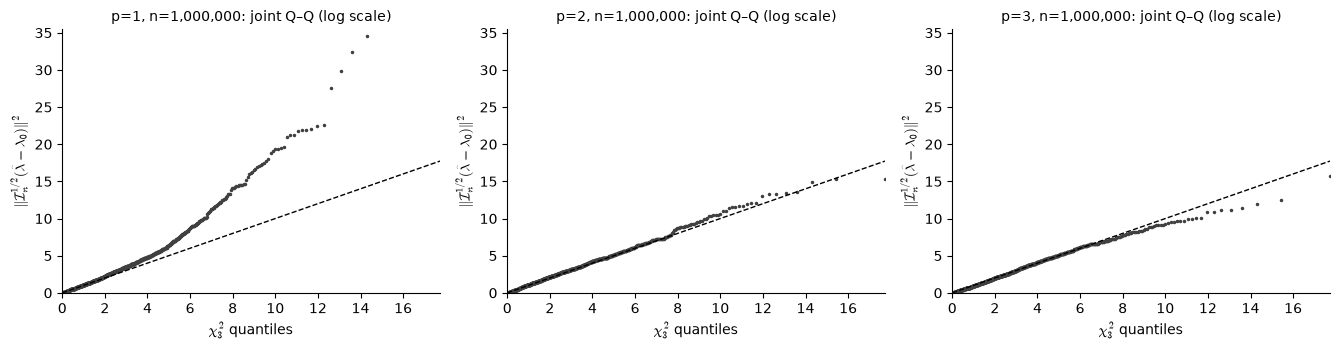

In [8]:
for scale in ("log", "original"):
    print(f"\n=== {scale} scale ===")
    for p in PS:
        r = sim.to_log(res[p]) if scale == "log" else res[p]
        print(f"p = {p}:      skewness (s,l,t)       excess kurtosis (s,l,t)   KS distance (s,l,t)    mean Q (target 3)")
        for i, n in enumerate(r["n"]):
            z, q = sim.standardized(r, i)
            sk, ku = stats.skew(z), stats.kurtosis(z)
            ks = [stats.kstest(z[:, j], "norm").statistic for j in range(3)]
            print(f"  n={n:>8d}  " + " ".join(f"{v:6.2f}" for v in sk) + "   " + " ".join(f"{v:6.2f}" for v in ku)
                  + "   " + " ".join(f"{v:5.3f}" for v in ks) + f"   {q.mean():6.2f}")

fig, axes = plt.subplots(1, len(PS), figsize=(4.5 * len(PS), 3.6), squeeze=False)
for ax, p in zip(axes[0], PS):
    r = sim.to_log(res[p]); i = len(r["n"]) - 1; _, q = sim.standardized(r, i)
    qs = np.sort(q); th = stats.chi2.ppf((np.arange(1, q.size + 1) - 0.5) / q.size, 3)
    ax.plot(th, qs, ".", ms=3, color="0.25"); m = max(th.max(), 16)
    ax.plot([0, m], [0, m], "k--", lw=1); ax.set_xlim(0, m); ax.set_ylim(0, 2 * m)
    ax.set_xlabel(r"$\chi^2_3$ quantiles"); ax.set_ylabel(r"$\|\mathcal{I}_n^{1/2}(\hat\lambda-\lambda_0)\|^2$")
    ax.set_title(f"p={p}, n={r['n'][i]:,}: joint Q–Q (log scale)", fontsize=10)
fig.tight_layout(); plt.show()

## 7. Consistency: estimates across replicates

Mean ± one standard deviation of $\hat\theta_j$ over the replicates, with the truth as a dashed line.

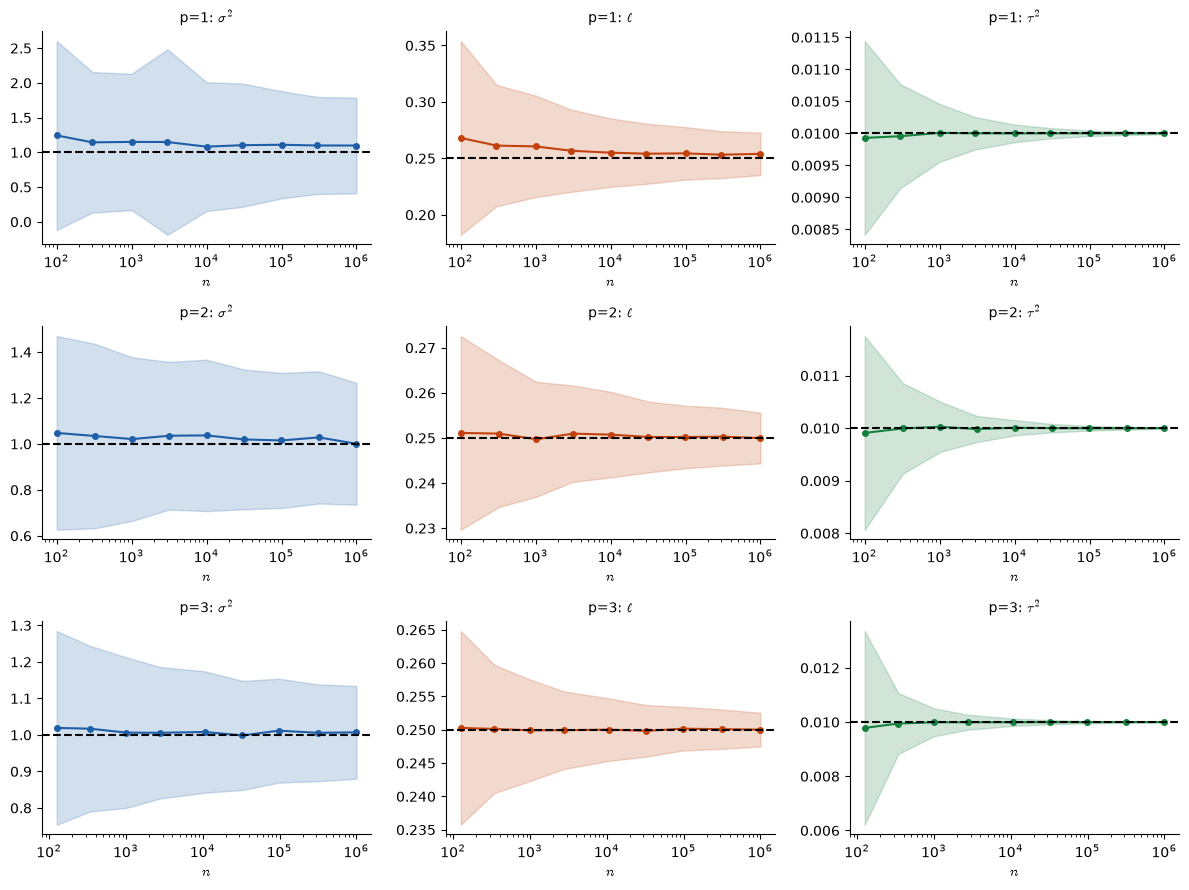

In [9]:
fig, axes = plt.subplots(len(PS), 3, figsize=(12, 3 * len(PS)), squeeze=False)
for r, p in enumerate(PS):
    est, n, th0 = res[p]["est"], res[p]["n"], res[p]["theta0"]
    for j in range(3):
        ax = axes[r, j]; m, s = est[:, :, j].mean(1), est[:, :, j].std(1, ddof=1)
        ax.fill_between(n, m - s, m + s, color=sim.COL[j], alpha=0.2)
        ax.plot(n, m, "o-", color=sim.COL[j], ms=4); ax.axhline(th0[j], ls="--", color="k")
        ax.set_xscale("log"); ax.set_xlabel("$n$"); ax.set_title(f"p={p}: {sim.PAR_LABELS[j]}", fontsize=10)
fig.tight_layout(); plt.show()

## 8. Numbers quoted in the paper

Every number in Section 4 and Appendix D of the paper that comes from the simulations, in order of appearance. The Appendix D.9 checks are in Section 1, the local slopes of Appendix D.8 in Section 5, and the normality diagnostics of Appendix D.6 in Section 6.

### Table 1 and Sections 4.1–4.2

In [10]:
sim.print_slope_table(res)

S = {p: sim.summarize(sim.to_log(res[p])) for p in PS}

print("\nEstimates on the boundary of Theta:")
total = 0
for p in PS:
    e, b = res[p]["est"], res[p]["bounds"]
    hit = np.isclose(e, b[:, 0], rtol=1e-3) | np.isclose(e, b[:, 1], rtol=1e-3)   # (n, replicate, parameter)
    total += hit.any(2).sum()
    for i, j in zip(*np.nonzero(hit.any(1))):
        print(f"   p={p}, n={res[p]['n'][i]}: {hit[i, :, j].sum()} estimate(s) of {['sigma^2', 'ell', 'tau^2'][j]}")
print(f"   {total} of {sum(res[p]['est'].shape[0] * res[p]['est'].shape[1] for p in PS)} fits have a coordinate on the boundary")

print("\nRMSE vs asymptotic SD of log sigma^2 and log ell, max over n of |RMSE / asy.SD - 1|:")
for p in PS:
    n = S[p]["n"]; dev = np.abs(S[p]["rmse"][:, :2] / S[p]["sd_fisher"][:, :2] - 1)
    print(f"   p={p}: all n {dev.max():.1%}, n >= 10^3 {dev[n >= 1000].max():.1%}")

print("\nFactor by which the RMSE falls from the smallest to the largest n (log scale):")
for p in PS:
    f = S[p]["rmse"][0] / S[p]["rmse"][-1]
    print(f"   p={p}: log sigma^2 {f[0]:.2f}, log ell {f[1]:.2f}, log tau^2 {f[2]:.0f}")

print("\nsqrt(n) RMSE(log tau^2) vs its limit sqrt(2), max relative deviation for n >= 3 x 10^3:")
for p in PS:
    n = S[p]["n"]; dev = np.abs(np.sqrt(n) * S[p]["rmse"][:, 2] / np.sqrt(2) - 1)
    print(f"   p={p}: {dev[n >= 3000].max():.1%}")
if 2 in PS:
    e = res[2]["est"][-1, :, 2] - res[2]["theta0"][2]
    print(f"   p=2, n=10^6: sqrt(n) RMSE(tau^2) on the original scale = {np.sqrt(res[2]['n'][-1] * np.mean(e ** 2)):.4f}"
          f" (limit sqrt(2) tau_0^2 = {np.sqrt(2) * res[2]['theta0'][2]:.5f})")


Table 1 (log scale): fitted slopes over the simulated n
                      RMSE IQR/1.349    asy.SD    theory
log sigma^2 p=1      -0.49     -0.49     -0.35      -0.5
log sigma^2 p=2      -0.75     -0.72     -0.74        -1
log sigma^2 p=3      -1.34     -1.48     -1.32      -1.5
    log ell p=1      -2.05     -1.81     -1.66      -1.5
    log ell p=2      -2.32     -2.24     -2.22        -2
    log ell p=3      -3.11     -3.11     -3.09      -2.5
  log tau^2 p=1      -0.50     -0.50     -0.50      -0.5
  log tau^2 p=2      -0.52     -0.53     -0.52      -0.5
  log tau^2 p=3      -0.60     -0.58     -0.58      -0.5



Estimates on the boundary of Theta:
   p=1, n=100: 1 estimate(s) of ell
   p=3, n=125: 2 estimate(s) of tau^2
   3 of 27000 fits have a coordinate on the boundary

RMSE vs asymptotic SD of log sigma^2 and log ell, max over n of |RMSE / asy.SD - 1|:
   p=1: all n 54.3%, n >= 10^3 44.8%
   p=2: all n 9.5%, n >= 10^3 5.5%
   p=3: all n 6.4%, n >= 10^3 6.4%

Factor by which the RMSE falls from the smallest to the largest n (log scale):
   p=1: log sigma^2 1.31, log ell 3.11, log tau^2 106
   p=2: log sigma^2 1.53, log ell 3.76, log tau^2 131
   p=3: log sigma^2 2.08, log ell 5.75, log tau^2 358

sqrt(n) RMSE(log tau^2) vs its limit sqrt(2), max relative deviation for n >= 3 x 10^3:
   p=1: 5.2%
   p=2: 2.9%
   p=3: 5.9%
   p=2, n=10^6: sqrt(n) RMSE(tau^2) on the original scale = 0.0143 (limit sqrt(2) tau_0^2 = 0.01414)


### Appendix D.3: profile likelihood of the extreme $p=1$ fits on 400 lengthscales

For the three largest $\hat\sigma^2$ at each $p=1$ sample size from $10^2$ to $3\times10^4$, the profile likelihood (maximised over $\sigma^2,\tau^2$) is evaluated on 400 log-spaced lengthscales. A nonnegative gap means that no grid point beats the computed MLE; the profile's local maxima on the grid are listed. This cell takes a few minutes.

In [11]:
def profile_check(i, r):
    n = int(res[1]["n"][i])
    seed = sim.replicate_seeds(1, len(res[1]["n"]), res[1]["est"].shape[1])[i, r]
    Y = sim.simulate(1, n, sim.THETA0, np.random.default_rng(int(seed))); E = float(Y @ Y)
    ls = np.exp(np.linspace(*np.log(sim.BOUNDS["l"]), 400))
    prof = np.array([sim._profile(l, 1, Y, E, n)[0] for l in ls])
    s, l, t = res[1]["est"][i, r]
    f_mle = sim._nll_st(np.log(s), np.log(t), *sim._suffstats(1, Y, l), n, E)[0]
    pad = np.r_[np.inf, prof, np.inf]
    peaks = ls[(prof < pad[:-2]) & (prof < pad[2:])]
    return n, r, res[1]["est"][i, r], prof.min() - f_mle, peaks

if 1 in PS:
    cases = [(i, int(r)) for i in range(6) for r in np.argsort(res[1]["est"][i, :, 0])[-3:]]
    out = Parallel(n_jobs=-1)(delayed(profile_check)(i, r) for i, r in cases)
    for n, r, est, gap, peaks in out:
        print(f"n={n:>6d}, replicate {r:3d}: MLE (s, l, t) = {np.round(est, 3)}; "
              f"best grid point minus MLE = {gap:+.1e} (negative log-lik); profile maxima at l = {np.round(peaks, 3)}")
    print(f"\nMLE at least as good as all 400 grid points in {sum(g >= -1e-6 for _, _, _, g, _ in out)} of {len(out)} cases; "
          f"profile with more than one local maximum in {sum(len(pk) > 1 for *_, pk in out)} of {len(out)}")

n=   100, replicate 907: MLE (s, l, t) = [7.906 0.635 0.012]; best grid point minus MLE = +6.7e-06 (negative log-lik); profile maxima at l = [0.636]
n=   100, replicate 678: MLE (s, l, t) = [8.479 2.    0.012]; best grid point minus MLE = -2.8e-14 (negative log-lik); profile maxima at l = [0.292 2.   ]
n=   100, replicate  38: MLE (s, l, t) = [2.9763e+01 9.5600e-01 1.0000e-02]; best grid point minus MLE = +7.8e-06 (negative log-lik); profile maxima at l = [0.468 0.955]
n=   300, replicate 858: MLE (s, l, t) = [5.947 0.291 0.01 ]; best grid point minus MLE = +4.6e-04 (negative log-lik); profile maxima at l = [0.29]
n=   300, replicate 744: MLE (s, l, t) = [8.772 0.613 0.01 ]; best grid point minus MLE = +1.7e-05 (negative log-lik); profile maxima at l = [0.612]
n=   300, replicate 971: MLE (s, l, t) = [1.6013e+01 4.9000e-01 1.0000e-02]; best grid point minus MLE = +6.4e-05 (negative log-lik); profile maxima at l = [0.491]
n=  1000, replicate 372: MLE (s, l, t) = [7.269 0.579 0.011]; bes

### Appendix D.6–D.8

In [12]:
if 3 in PS:
    z, _ = sim.standardized(sim.to_log(res[3]), len(res[3]["n"]) - 1)
    print("p=3, n=10^6, log scale: skewness (log s, log l) =", np.round(stats.skew(z[:, :2]), 2),
          "  KS distance =", np.round([stats.kstest(z[:, j], "norm").statistic for j in (0, 1)], 3))
if 1 in PS:
    r = S[1]["rmse"][:, :2] / S[1]["sd_fisher"][:, :2] - 1
    q = np.abs(S[1]["iqr"][:, :2] / S[1]["sd_fisher"][:, :2] - 1)
    print(f"p=1: RMSE / asy.SD - 1: log sigma^2 {r[0, 0]:.0%} at n={S[1]['n'][0]} -> {r[-1, 0]:.0%} at n={S[1]['n'][-1]};"
          f" log ell {r[0, 1]:.0%} -> {r[-1, 1]:.0%}")
    print(f"p=1: |IQR/1.349 / asy.SD - 1| between {q.min():.1%} and {q.max():.1%}")

# eigen-directions of R_n(l0) whose signal variance sigma_0^2 lambda_k exceeds tau_0^2
X = dense_design(3, 5); D2 = ((X[:, None, :] - X[None, :, :]) ** 2).sum(-1)
lam = np.linalg.eigvalsh(np.exp(-D2 / (2 * sim.THETA0["l"] ** 2)))
print(f"p=3, n=125: {np.sum(sim.THETA0['s'] * lam > sim.THETA0['t'])} of 125 eigen-directions have signal variance above tau_0^2")
cnt = [int(np.sum(sim.THETA0["s"] * sim.spectrum(n, sim.THETA0["l"], np.zeros(n))[0] > sim.THETA0["t"])) for n in sim.N_LIST[1]]
print(f"p=1, n = 10^2 ... 10^6: {cnt} such directions")

print("asymptotic SDs at n = 10^6 (log scale):")
for p in PS:
    print(f"   p={p}: log sigma^2 {S[p]['sd_fisher'][-1, 0]:.3f}, log ell {S[p]['sd_fisher'][-1, 1]:.4f}")

p=3, n=10^6, log scale: skewness (log s, log l) = [-0.05  0.  ]   KS distance = [0.017 0.018]
p=1: RMSE / asy.SD - 1: log sigma^2 18% at n=100 -> 10% at n=1000000; log ell 54% -> 26%
p=1: |IQR/1.349 / asy.SD - 1| between 3.5% and 20.4%
p=3, n=125: 96 of 125 eigen-directions have signal variance above tau_0^2


p=1, n = 10^2 ... 10^6: [7, 8, 8, 9, 9, 10, 10, 11, 11] such directions
asymptotic SDs at n = 10^6 (log scale):
   p=1: log sigma^2 0.587, log ell 0.0588
   p=2: log sigma^2 0.261, log ell 0.0219
   p=3: log sigma^2 0.124, log ell 0.0099
